In [56]:
!pip install category_encoders

zsh:1: command not found: pip


In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import datetime as dt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from skimage import color, data, img_as_float
from skimage.transform import resize, rotate

print("Libraries imported successfully.")

Libraries imported successfully.


In [58]:
dataset = pd.read_csv('NOLA_Surveillance.csv')
dataset.head()

/var/folders/3p/wpdcwlx57k93mldysxqtnprw0000gn/T/ipykernel_18125/3020394071.py:1: DtypeWarning: Columns (17,20,21,34) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('NOLA_Surveillance.csv')


,agency_code,agency_collection_num,collection_id,code,name,street,city,zip,region,site_code,site_name,site_street,site_city,site_zip,site_region,calculated_neighborhood,calculated_neighborhood_distance,calculated_city,calculated_city_distance,calculated_subcounty,calculated_county,calculated_state,longitude,latitude,coordinate_precision,group,identified_by,trap_type,lure,collection_date,disease_week,num_trap,trap_nights,trap_problem,comments,species,add_date,add_user,males,females - mixed
0,NOLA,1,2998124,504042,778 HARRISON AVE,778 HARRISON AVE,New Orleans,70124.0,"Orleans County (Louisiana, USA)",504042,778 HARRISON AVE,778 HARRISON AVE,New Orleans,70124.0,"Orleans County (Louisiana, USA)",NaN,NaN,NaN,NaN,New Orleans,NaN,NaN,-90.105888,30.004112,Exact,NaN,NOMTRCB Staff,GRVD,"Other, Infusion (hay or straw)",2018-02-27,9,1,1,N,NaN,Culex quinquefasciatus,2023-09-21 14:35,NaN,NaN,11.0
1,NOLA,2,2998125,504046,987 ROBERT E LEE BLVD,987 Allen Toussaint Blvd,New Orleans,70124.0,"Orleans County (Louisiana, USA)",504046,987 ROBERT E LEE BLVD,987 Allen Toussaint Blvd,New Orleans,70124.0,"Orleans County (Louisiana, USA)",NaN,NaN,NaN,NaN,New Orleans,NaN,NaN,-90.098821,30.019220,Exact,NaN,NOMTRCB Staff,GRVD,"Other, Infusion (hay or straw)",2018-02-27,9,1,1,N,NaN,Culex quinquefasciatus,2023-09-21 14:35,NaN,NaN,7.0
2,NOLA,3,2998126,504025,401 CITY PARK AVE,401 CITY PARK AVE,New Orleans,70119.0,"Orleans County (Louisiana, USA)",504025,401 CITY PARK AVE,401 CITY PARK AVE,New Orleans,70119.0,"Orleans County (Louisiana, USA)",NaN,NaN,NaN,NaN,New Orleans,NaN,NaN,-90.107377,29.984114,Exact,NaN,NOMTRCB Staff,GRVD,"Other, Infusion (hay or straw)",2018-02-27,9,1,1,N,NaN,Culex quinquefasciatus,2023-09-21 14:35,NaN,NaN,3.0
3,NOLA,4,2998127,504045,964 N CARROLLTON AVE,964 N CARROLLTON AVE,New Orleans,70119.0,"Orleans County (Louisiana, USA)",504045,964 N CARROLLTON AVE,964 N CARROLLTON AVE,New Orleans,70119.0,"Orleans County (Louisiana, USA)",NaN,NaN,NaN,NaN,New Orleans,NaN,NaN,-90.092618,29.981348,Exact,NaN,NOMTRCB Staff,GRVD,"Other, Infusion (hay or straw)",2018-02-27,9,1,1,N,NaN,Culex quinquefasciatus,2023-09-21 14:35,NaN,3.0,16.0
4,NOLA,5,2998128,504002,1001 HARRISON AVE,1001 HARRISON AVE,New Orleans,70124.0,"Orleans County (Louisiana, USA)",504002,1001 HARRISON AVE,1001 HARRISON AVE,New Orleans,70124.0,"Orleans County (Louisiana, USA)",NaN,NaN,NaN,NaN,New Orleans,NaN,NaN,-90.098061,30.004274,Exact,NaN,NOMTRCB Staff,GRVD,"Other, Infusion (hay or straw)",2018-02-27,9,1,1,N,NaN,Culex quinquefasciatus,2023-09-21 14:35,NaN,NaN,12.0


In [59]:
#How many rows and columns does the dataset have?
dataset.shape 

(71697, 40)

In [60]:
dataset.isnull().sum() #shows the missing data

agency_code                             0
agency_collection_num                   0
collection_id                           0
code                                    0
name                                    0
street                              14695
city                                17863
zip                                 21096
region                                  0
site_code                               0
site_name                               0
site_street                         14695
site_city                           20456
site_zip                            21096
site_region                             0
calculated_neighborhood             71697
calculated_neighborhood_distance    71697
calculated_city                     66781
calculated_city_distance            66781
calculated_subcounty                    0
calculated_county                   66781
calculated_state                    66781
longitude                               0
latitude                          

In [94]:
#filter through columns and rows
file_path = 'NOLA_Surveillance.csv'


#columns = pd.read_csv(filepath, nrows=0).columns.tolist()

columns_to_keep = [
    "site_code",
    "site_name",
    "trap_type",
    "trap_problem",
    "collection_date",
    "species",
    "females - mixed",
]
df = pd.read_csv(file_path, usecols=columns_to_keep)

species_matches = (
    df["species"]
    .str.strip()
    .str.casefold()
    .isin([
        "culex quinquefasciatus",
        "culex quinx"
    ])
)


trap_matches = (
    df["trap_type"]
    .str.strip()
    .str.casefold()
    .eq("grvd")
)

filtered_df = df.loc[
    species_matches & trap_matches
].copy()

#display(filtered_df)
#filtered_df = df.loc[species_matches].copy()
filtered_df.to_csv(
    "NOLA_filtered_GRVD.csv",
    index=False
)

print("NOLA_filtered_GRVD.csv was created")
print("Rows and columns:", filtered_df.shape)



NOLA_filtered_GRVD.csv was created
Rows and columns: (18201, 7)


In [ ]:
#checks if there are any trap problem = Y
trap_problem_y = (
    df["trap_problem"]
    .astype("string")
    .str.strip()
    .str.casefold()
    .eq("y")
)

print("Any Y values:", trap_problem_y.any())
print("Number of Y values:", trap_problem_y.sum())

Any Y values: True
Number of Y values: 1504


In [62]:
# Making sure the female count is numeric
filtered_df["females - mixed"] = pd.to_numeric(
    filtered_df["females - mixed"],
    errors="coerce"
)

# Keep one record per site per day
site_day_df = (
    filtered_df
    .groupby(
        ["collection_date", "site_code", "site_name"],
        dropna=False,
        as_index=False
    )
    .agg(
        trap_type=("trap_type", "first"),
        species=("species", "first"),
        female_mixed_max=("females - mixed", "max"),
        number_of_original_records=("females - mixed", "size")
    )
    .rename(
        columns={
            "female_mixed_max": "females - mixed"
        }
    )
)

#display(site_day_df)


In [63]:
print("Number of rows:", len(site_day_df))#display how many rows and columns are shown

Number of rows: 18129


In [64]:
site_day_df.isnull().sum() #check missing or null values in your data

collection_date                0
site_code                      0
site_name                      0
trap_type                      0
species                        0
females - mixed               87
number_of_original_records     0
dtype: int64

In [65]:
# Convert to datetime and remove any time portion
dates = pd.to_datetime(
    site_day_df["collection_date"],
    errors="coerce"
).dt.floor("D")

# ISO weekday: Monday=1, Tuesday=2, ..., Sunday=7
iso_weekday = dates.dt.isocalendar().day

# Number of days to move backward to Monday
days_to_subtract = (iso_weekday - 1).fillna(0).astype(int)

site_day_df["collection_date"] = dates

site_day_df["week_monday"] = (dates - pd.to_timedelta(days_to_subtract, unit="D"))

In [ ]:
'''site_day_df.to_csv("NOLA_mondays_fixed.csv",index=False)

print("NOLA_mondays_fixed.csv was created")
print("Rows and columns:", site_day_df.shape)'''

NOLA_mondays_fixed.csv was created
Rows and columns: (18129, 8)


In [69]:
#this find the average female count of each trap for one day

def calculate_total(values): #this function adds the female mosquito counts 
    return values.sum(min_count=1)

weekly_summary = (
site_day_df
.groupby('week_monday')
.agg(
    total_females=("females - mixed", calculate_total),
    number_of_traps=("females - mixed", "size")
)
.reset_index()
)
#fix the daily_summary
weekly_summary ["females - mixed"] = (
    weekly_summary["total_females"] /
    weekly_summary["number_of_traps"]
)

#Nan
#display(weekly_summary)

In [73]:
weekly_summary.to_csv("NOLA_mondays_fixed.csv",index=False)

print("NOLA_mondays_fixed.csv was created")
print("Rows and columns:", weekly_summary.shape)

NOLA_mondays_fixed.csv was created
Rows and columns: (487, 4)


In [111]:
ceph_cols = ("#a8ddb5", "#7bccc4", "#4eb3d3", "#08589e", "#8c6bb1", "#88419d",
              "#8c96c6", "#6e016b", "#fdcc8a", "#fec44f", "#fc8d59", "#993404",
              "#ef6548", "#d7301f", "#fcc5c0", "#fa9fb5", "#f768a1", "#ae017e")  

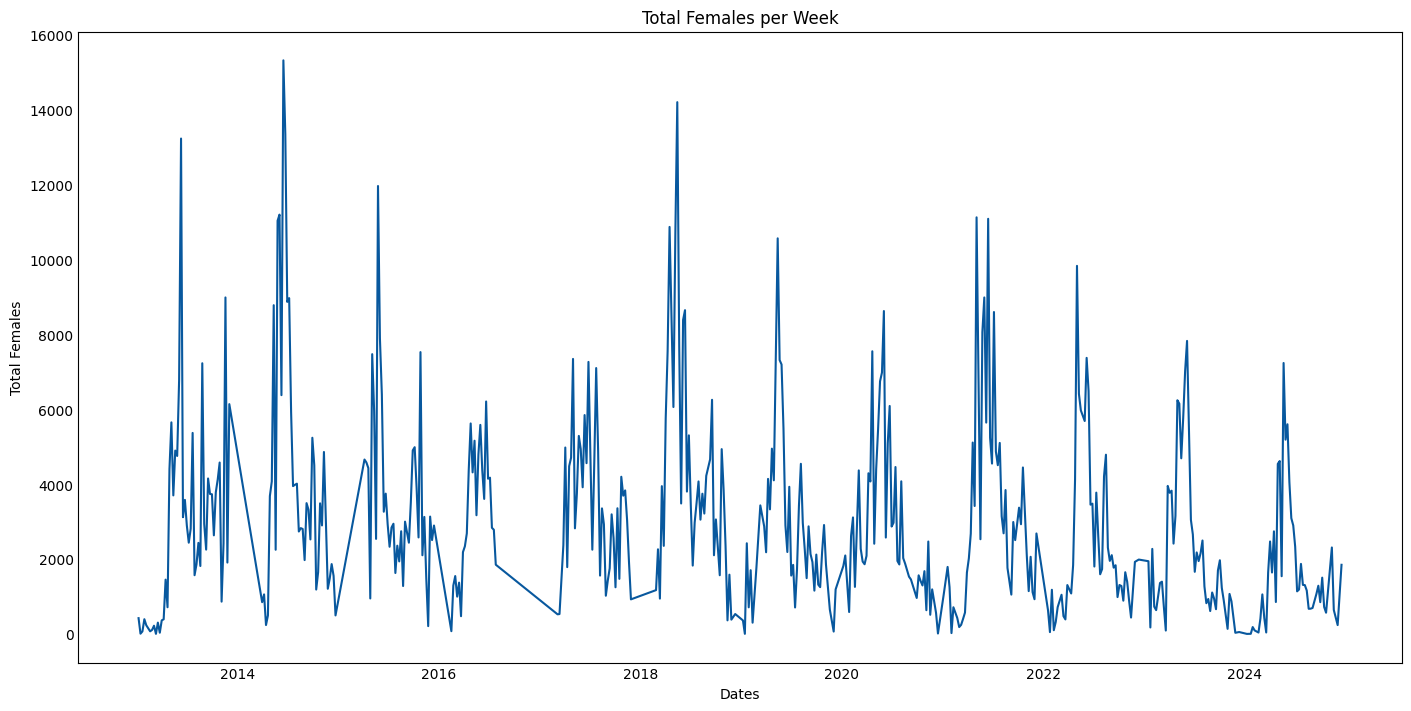

In [113]:
import matplotlib.pyplot as plt
import numpy as np

# Data for plotting 'Total Females per Week'
#PLOT 1
x_axis = weekly_summary['week_monday']
y_axis = weekly_summary['total_females']

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

ax.plot(x_axis, y_axis, color='#08589e')

ax.set(xlabel='Dates', ylabel='Total Females',
       title='Total Females per Week')
ax.grid()

fig.savefig("total_females_per_week.png")
plt.show()



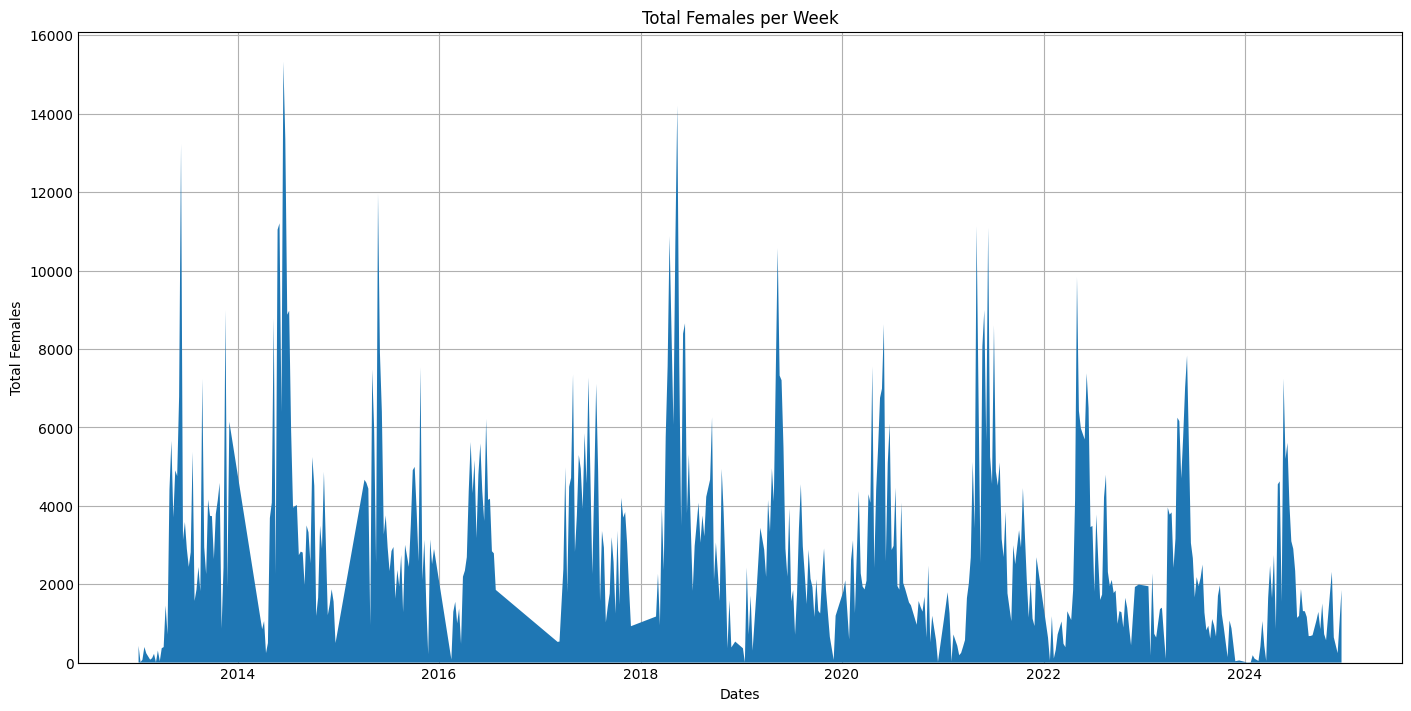

In [112]:
#PLOT 2
plt.style.use('_mpl-gallery')
# plot
fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)

ax.stackplot(x_axis, y_axis)

ax.set(xlabel='Dates', ylabel='Total Females',
       title='Total Females per Week')

plt.show()

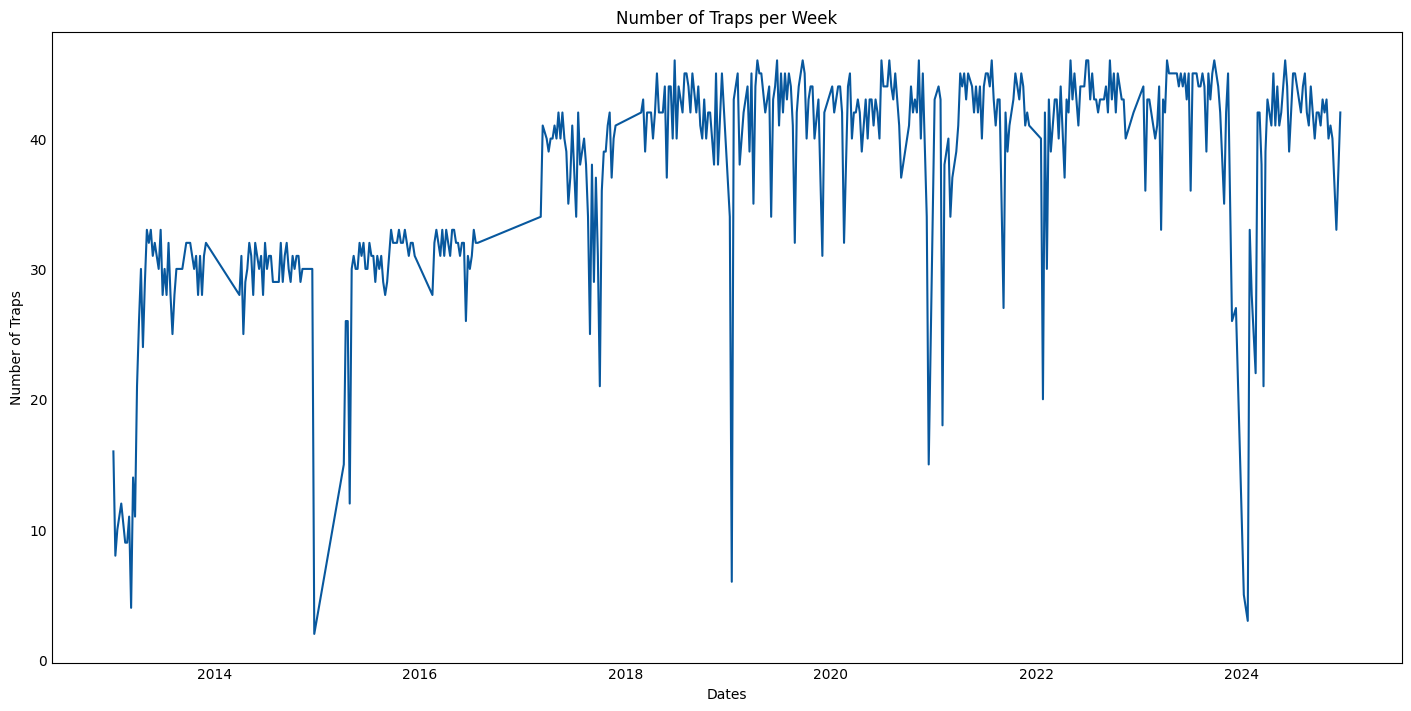

In [114]:

# Data for plotting 'Number of Traps per Week'
x_axis2 = weekly_summary['week_monday']
y_axis2 = weekly_summary['number_of_traps']

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
ax.plot(x_axis2, y_axis2, color='#08589e')

ax.set(xlabel='Dates', ylabel='Number of Traps',
       title='Number of Traps per Week')
ax.grid()

fig.savefig("number_of_traps_per_week.png")
plt.show()

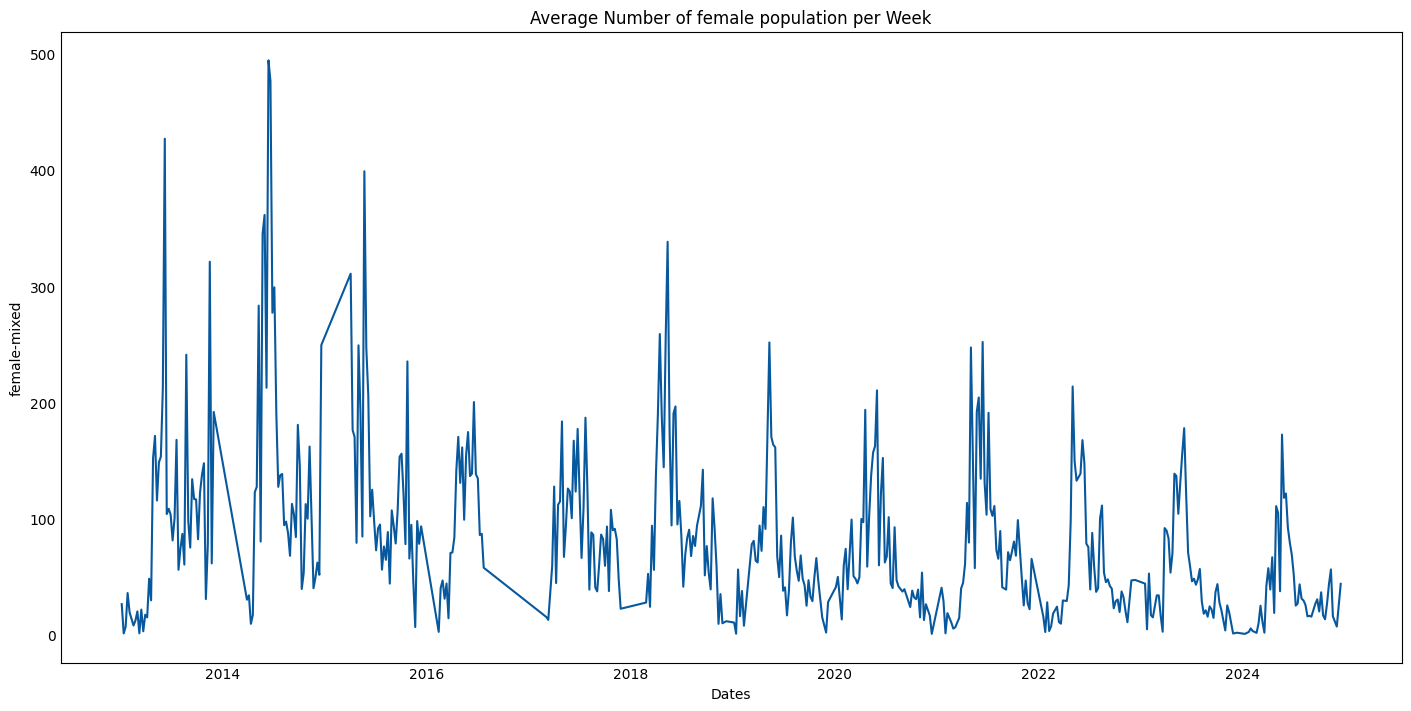

In [115]:

# Data for plotting 'Number of Traps per Week'
x_axis3 = weekly_summary['week_monday']
y_axis3 = weekly_summary['females - mixed']

fig, ax = plt.subplots(figsize=(14, 7), constrained_layout=True)
ax.plot(x_axis3, y_axis3, color='#08589e')

ax.set(xlabel='Dates', ylabel='female-mixed',
       title='Average Number of female population per Week')
ax.grid()

fig.savefig("average_number_of_female_per_week.png")
plt.show()

In [109]:
'''output_df = (weekly_summary[["week_monday", "females - mixed"]]
    .rename(columns={"week_monday": "date", "females - mixed": "mosq_per_trap_night"
                     }
                     )
.copy()
)

display(output_df)

output_df.to_csv(
    "NOLA_culexquin.csv",
    index=False
)

print("NOLA_culexquin.csv is created")'''

'output_df = (weekly_summary[["week_monday", "females - mixed"]]\n    .rename(columns={"week_monday": "date", "females - mixed": "mosq_per_trap_night"\n                     }\n                     )\n.copy()\n)\n\ndisplay(output_df)\n\noutput_df.to_csv(\n    "NOLA_culexquin.csv",\n    index=False\n)\n\nprint("NOLA_culexquin.csv is created")'